In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

In [3]:
warnings.filterwarnings('ignore')

In [45]:
df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [46]:
df.shape

(7787, 12)

In [47]:
df['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [48]:
# Top 5 countries on netflix
x = df['country'].value_counts().head()

In [49]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [50]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [51]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


In [52]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

In [53]:
df.isnull().sum()/(len(df))*100

show_id          0.000000
type             0.000000
title            0.000000
director        30.679337
cast             9.220496
country          6.510851
date_added       0.128419
release_year     0.000000
rating           0.089893
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

In [54]:
df = df.drop(columns='director')

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   cast          7069 non-null   str  
 4   country       7280 non-null   str  
 5   date_added    7777 non-null   str  
 6   release_year  7787 non-null   int64
 7   rating        7780 non-null   str  
 8   duration      7787 non-null   str  
 9   listed_in     7787 non-null   str  
 10  description   7787 non-null   str  
dtypes: int64(1), str(10)
memory usage: 669.3 KB


In [56]:
df = df.fillna({'date_added': 'Unknown'})
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   cast          7069 non-null   str  
 4   country       7280 non-null   str  
 5   date_added    7787 non-null   str  
 6   release_year  7787 non-null   int64
 7   rating        7780 non-null   str  
 8   duration      7787 non-null   str  
 9   listed_in     7787 non-null   str  
 10  description   7787 non-null   str  
dtypes: int64(1), str(10)
memory usage: 669.3 KB


In [57]:
#creating new year column from date_added column
def year_extractor(date:str):
    ans = date[-4:]
    return ans

df['year'] = df['date_added'].apply(year_extractor)

In [58]:
df['year'].value_counts()

year
2019    2153
2020    2009
2018    1685
2017    1225
2016     443
2021     117
2015      88
2014      25
2011      13
2013      11
nown      10
2012       3
2008       2
2009       2
2010       1
Name: count, dtype: int64

In [59]:
df['year'] = df['year'].replace('nown', '2019')


In [60]:
df.isnull().sum()

show_id           0
type              0
title             0
cast            718
country         507
date_added        0
release_year      0
rating            7
duration          0
listed_in         0
description       0
year              0
dtype: int64

In [62]:
df = df.fillna({'country': 'United States'})
df.isnull().sum()

show_id           0
type              0
title             0
cast            718
country           0
date_added        0
release_year      0
rating            7
duration          0
listed_in         0
description       0
year              0
dtype: int64

In [63]:
df.rating.value_counts()

rating
TV-MA       2863
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [66]:
# df.rating.fillna('TV-MA', inplace=True)
df = df.fillna({'rating': 'TV-MA'})

In [67]:
df.isnull().sum()

show_id           0
type              0
title             0
cast            718
country           0
date_added        0
release_year      0
rating            0
duration          0
listed_in         0
description       0
year              0
dtype: int64

In [68]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   cast          7069 non-null   str  
 4   country       7787 non-null   str  
 5   date_added    7787 non-null   str  
 6   release_year  7787 non-null   int64
 7   rating        7787 non-null   str  
 8   duration      7787 non-null   str  
 9   listed_in     7787 non-null   str  
 10  description   7787 non-null   str  
 11  year          7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB


Text(0, 0.5, 'Number of country')

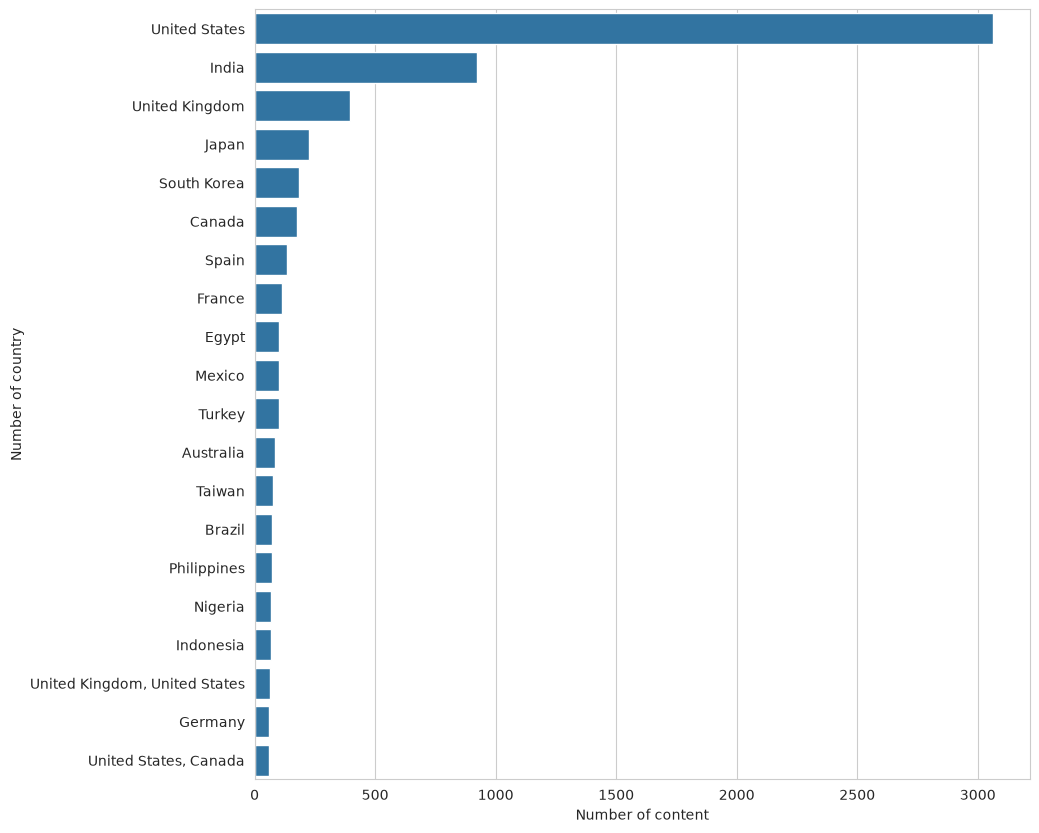

In [84]:
# PLOTTING THE VALUES WITH USE OF SEABORN AND MATPLOTLIB

# displaying all the countries with most contribution to netflix content
x = pd.Series(df.country.value_counts().head(20))
plt.figure(figsize=(10,10))
sns.set_style("whitegrid")   #set style to whitegrid
ax= sns.barplot(x=x.values, y=x.index)   #using bar for visualization
ax.set_xlabel("Number of content")
ax.set_ylabel("Number of country")

<Axes: xlabel='type', ylabel='count'>

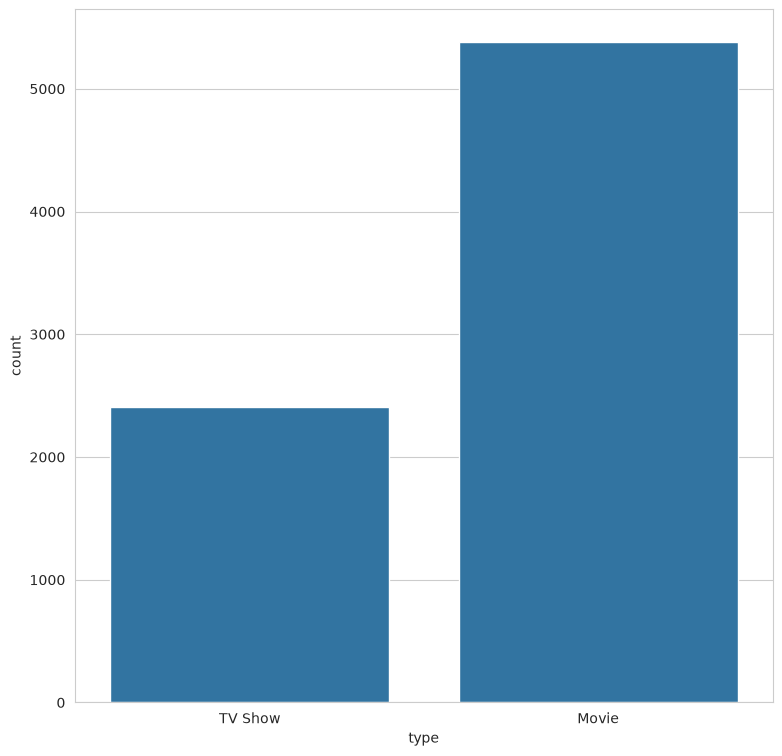

In [87]:
#distribution of type of content on netflix 
#69.1 percent of contents are movies while 30 percent are tv shows

plt.figure(figsize=(9,9))
x= df.type.value_counts()
sns.countplot(x= "type",data= df)


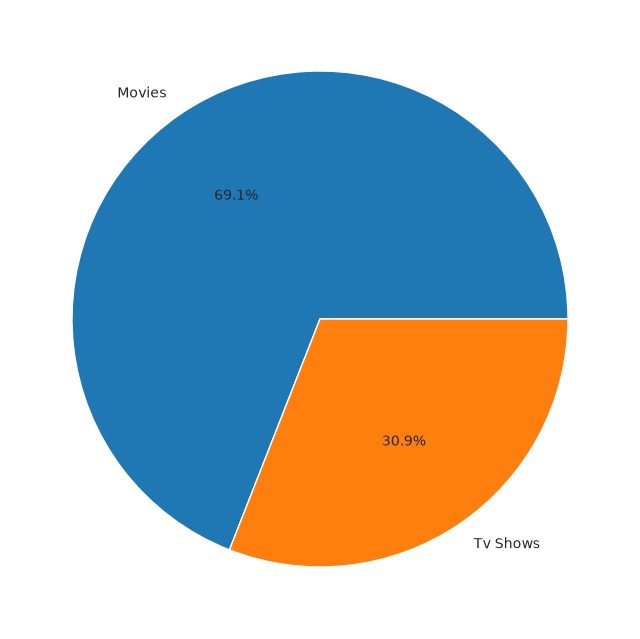

In [88]:
plt.figure(figsize=(8,10))

label= ["Movies","Tv Shows"]

plt.pie(x.values, labels= label ,autopct= "%1.1f%%") # visualizing using pie
plt.show()   

<Axes: xlabel='Year'>

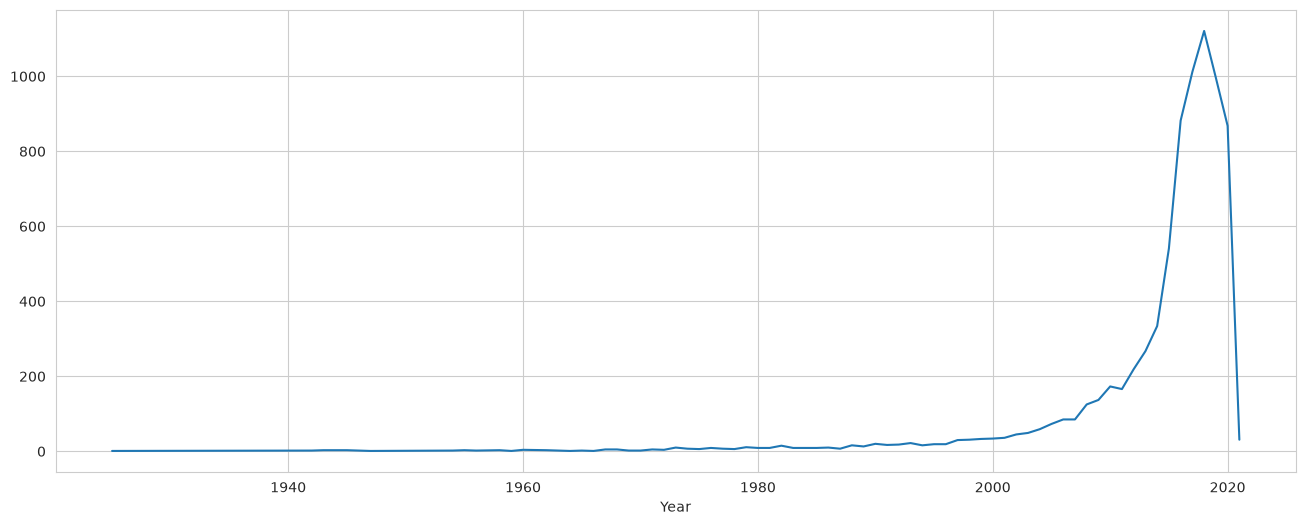

In [92]:
#Netflix content releases over the years
x= df.release_year.value_counts()
plt.figure(figsize=(16,6))
plt.xlabel("Year")

sns.lineplot(x=x.index ,y= x.values)

Text(0, 0.5, 'No of content')

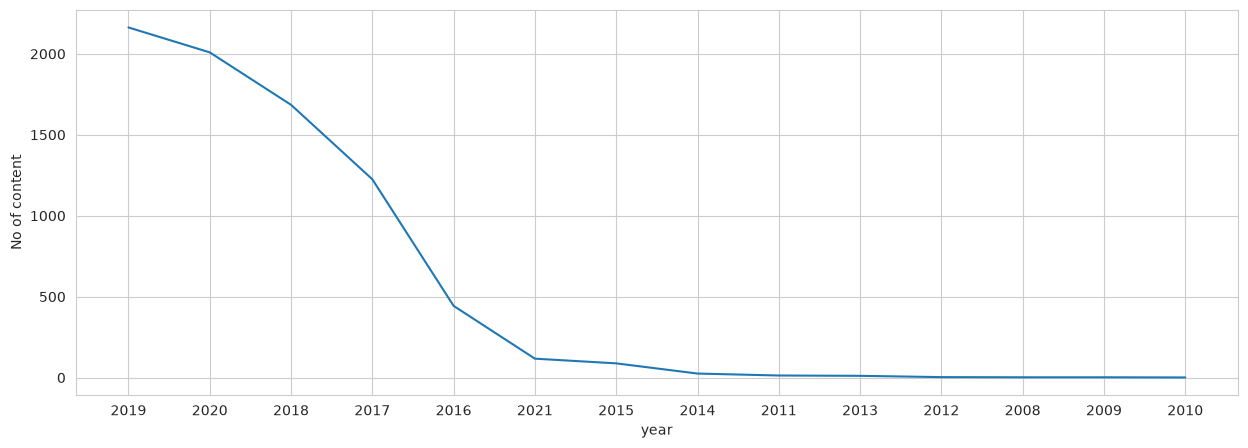

In [94]:
#Number of content added on netflix over the years
plt.figure(figsize=(15,5))
x= df.year.value_counts()
ax= sns.lineplot(x=x.index,y=x.values)
ax.set_ylabel("No of content")

<Axes: ylabel='year'>

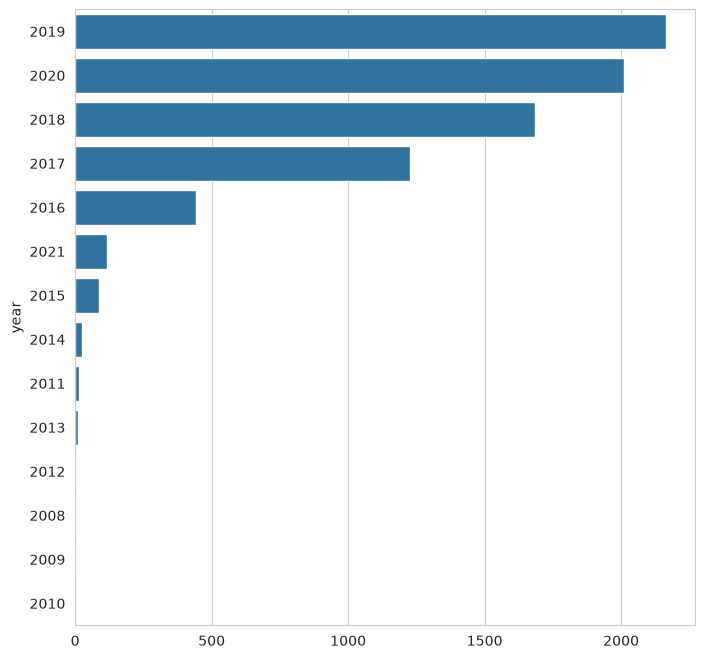

In [98]:
plt.figure(figsize=(8,8))

sns.barplot(x = x.values,y = x.index)


<Axes: xlabel='rating', ylabel='count'>

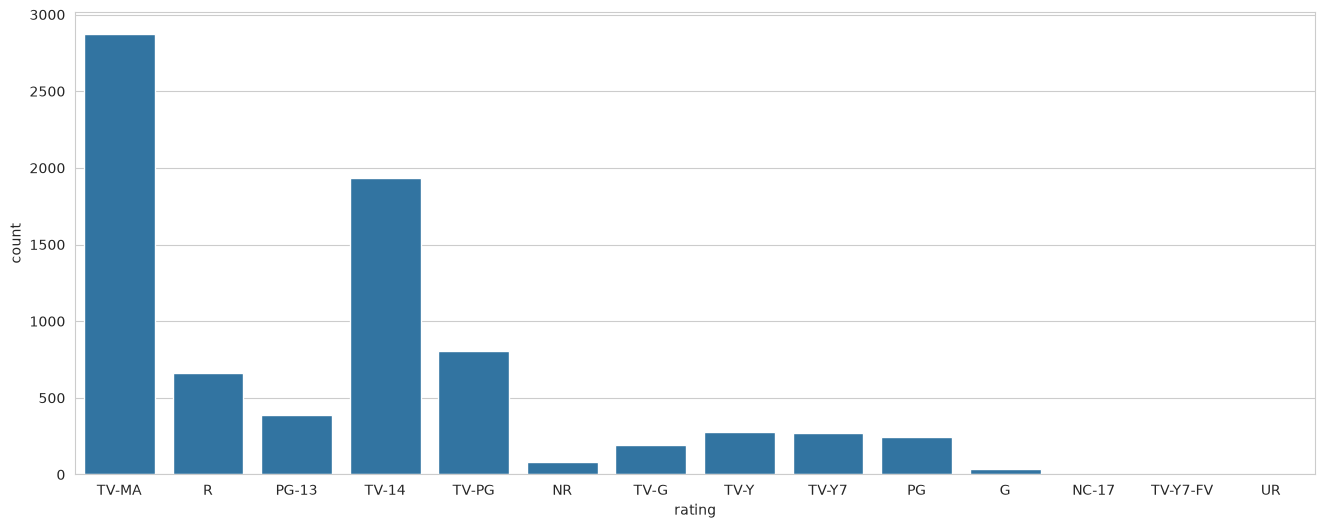

In [99]:
#content distribution based on rating
#most of the content of netflix is either rated TV-MA or TV-14
plt.figure(figsize=(16,6))
sns.countplot(x= "rating",data= df)

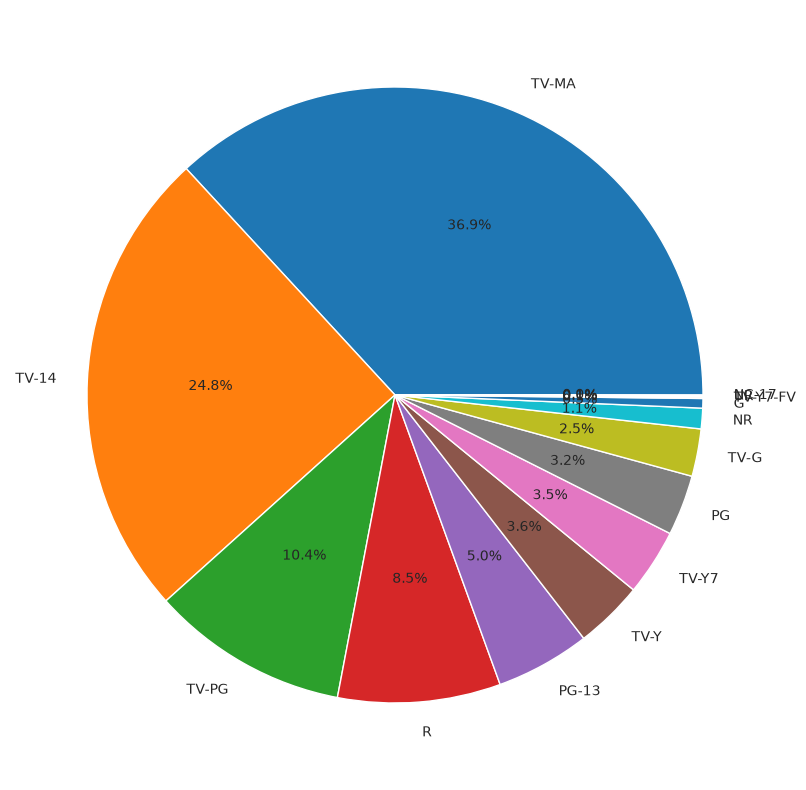

In [100]:
x= df.rating.value_counts()
plt.figure(figsize=(10,10))

labels= list(x.index)
plt.pie(x.values,labels= labels,autopct= "%1.1f%%")
plt.show()

In [101]:
# This is just data analysis project to get some insights
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   cast          7069 non-null   str  
 4   country       7787 non-null   str  
 5   date_added    7787 non-null   str  
 6   release_year  7787 non-null   int64
 7   rating        7787 non-null   str  
 8   duration      7787 non-null   str  
 9   listed_in     7787 non-null   str  
 10  description   7787 non-null   str  
 11  year          7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 730.2 KB
